/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/requests/__init__.py:89: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (3.0.4) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "


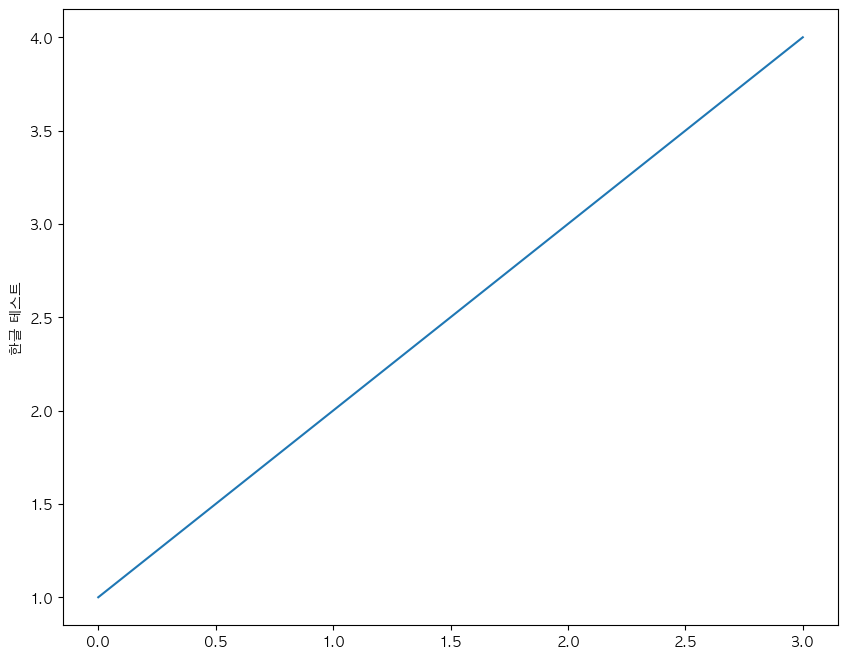

In [2]:
## import library
import trino
import pandas as pd
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


plt.rcParams['figure.figsize'] = [10, 8]

conn = trino.dbapi.connect(
    host='kakaoent-presto-adhoc.kakaoent.io',
    port=8443,
    user='samuel-ch',
    catalog='hadoop_kent',
    schema='default',                          # 사용할 Database 지정
    http_scheme='https',
    auth=trino.auth.BasicAuthentication("samuel-ch", "melon!Q2w3e"),  # 카카오 LDAP이 아닌 하둡 LDAP 입력
    http_headers={
        'X-Presto-User': 'samuel-ch',
        'X-Presto-Time-Zone': 'Asia/Seoul'
    },
)
cur = conn.cursor()

# Set CSS properties for th elements in dataframe
th_props = [
  ('font-size', '11px'),
  ('text-align', 'center'),
  ('font-weight', 'bold'),
  ('color', '#6d6d6d'),
  ('background-color', '#f7f7f9')
  ]

# Set CSS properties for td elements in dataframe
td_props = [
  ('font-size', '11px')
  ]

# Set table styles
styles = [
  dict(selector="th", props=th_props),
  dict(selector="td", props=td_props)
  ]

cm = sns.light_palette("green", as_cmap=True)

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# AppleGothic 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'

# 테스트 플롯
plt.plot([1, 2, 3, 4])
plt.ylabel('한글 테스트')
plt.show()

In [3]:
# pandas를 사용하여 CSV 파일 로드
import pandas as pd

# CSV 파일 경로
csv_file_path = "event_user_data.csv"

# CSV 파일 읽기
try:
    event_user_data = pd.read_csv(csv_file_path)
    print("CSV 파일이 성공적으로 로드되었습니다.")
    print(event_user_data.head())  # 데이터 미리보기
except FileNotFoundError:
    print(f"파일을 찾을 수 없습니다: {csv_file_path}")
except Exception as e:
    print(f"CSV 파일 로드 중 오류 발생: {e}")

CSV 파일이 성공적으로 로드되었습니다.
   event_id  category_id event_category                          title  \
0     36277       100067          공연이벤트   노엘 갤러거 하이 플라잉 버즈 내한공연 초대 이벤트   
1     36284       100067          공연이벤트               LANY 내한공연 초대 이벤트   
2     36288       100067          공연이벤트  IVE THE 1ST WORLD TOUR 초대 이벤트   
3     36293       100067          공연이벤트   라이엇게임즈 VALORANT 챔스 서울 초대 이벤트   
4     36421       100067          공연이벤트     The Kid LAROI 내한 공연 초대 이벤트   

         start_date          end_date     pv     lv  event_ent_user_cnt  \
0  2024-07-15 12:00  2024-07-19 23:59  13525   7788                 702   
1  2024-07-19 12:00  2024-08-02 23:59  24923  15273                1693   
2  2024-07-23 12:00  2024-07-31 23:59  42561  20311                4194   
3  2024-07-24 12:00  2024-08-07 23:59  26220  15332                1626   
4  2024-09-23 12:00  2024-10-07 23:59  12179   8191                 688   

   event_user_ratio  event_ent_new_prod_user_cnt  new_prod_ratio  
0          9.0

,event_category,event_id,pv,lv,event_ent_user_cnt,event_user_ratio,event_ent_new_prod_user_cnt,new_prod_ratio
0,공연이벤트,20,23153.75,13208.05,1961.05,13.61,28.00,1.66
1,멜론매거진이벤트,240,38038.20,23819.81,2084.14,9.89,75.10,3.54
2,멜론이벤트,25,207450.68,118499.56,22276.72,22.64,273.00,2.56
3,뮤직웨이브이벤트,97,41453.85,12431.48,2959.46,20.27,399.38,10.23


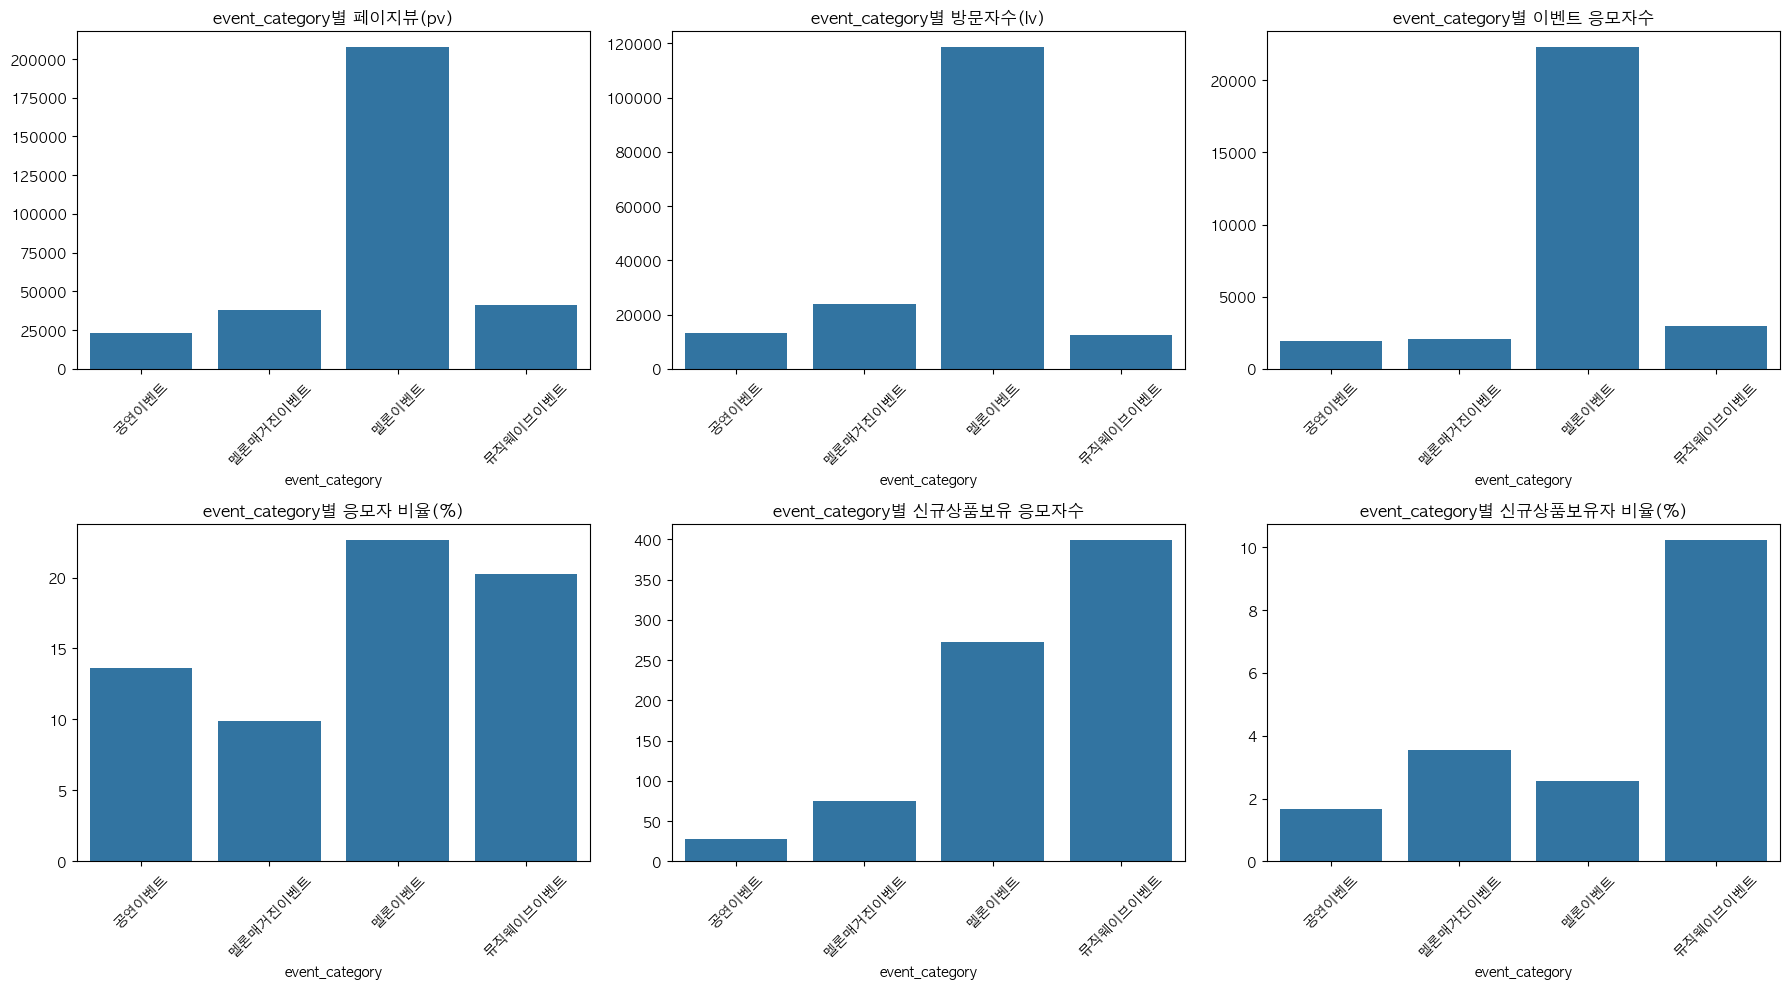

/var/folders/qw/6lks7c5d14scf7qtctm8m6jh0000gn/T/ipykernel_11255/3113829252.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


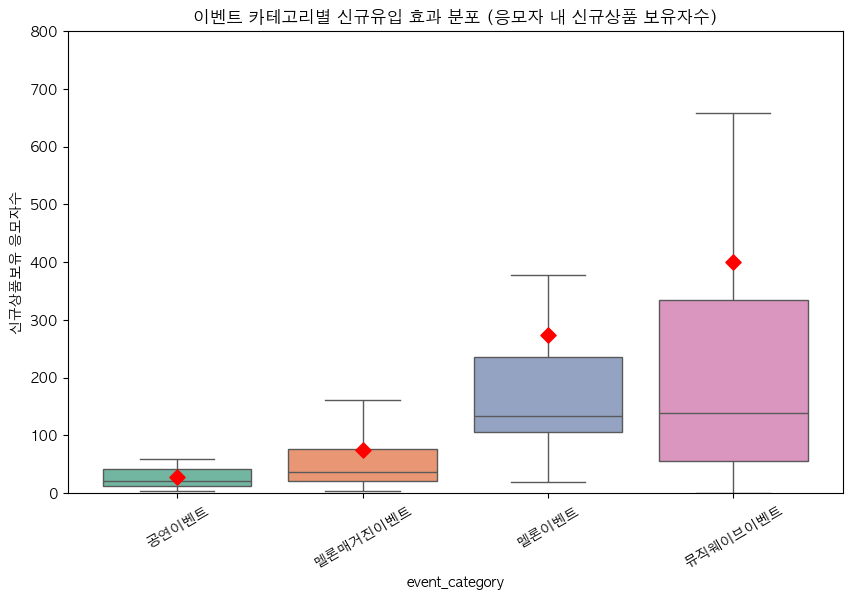

/var/folders/qw/6lks7c5d14scf7qtctm8m6jh0000gn/T/ipykernel_11255/3113829252.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


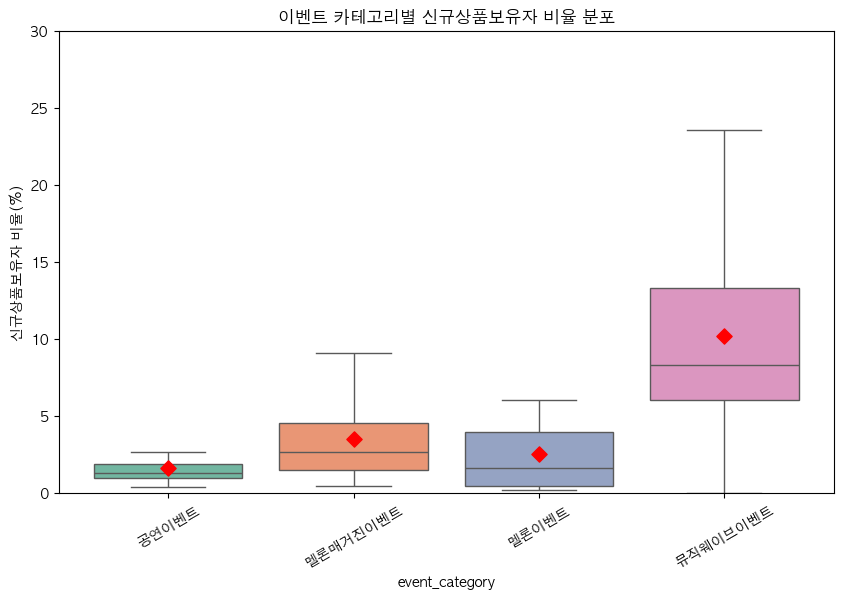

/var/folders/qw/6lks7c5d14scf7qtctm8m6jh0000gn/T/ipykernel_11255/3113829252.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


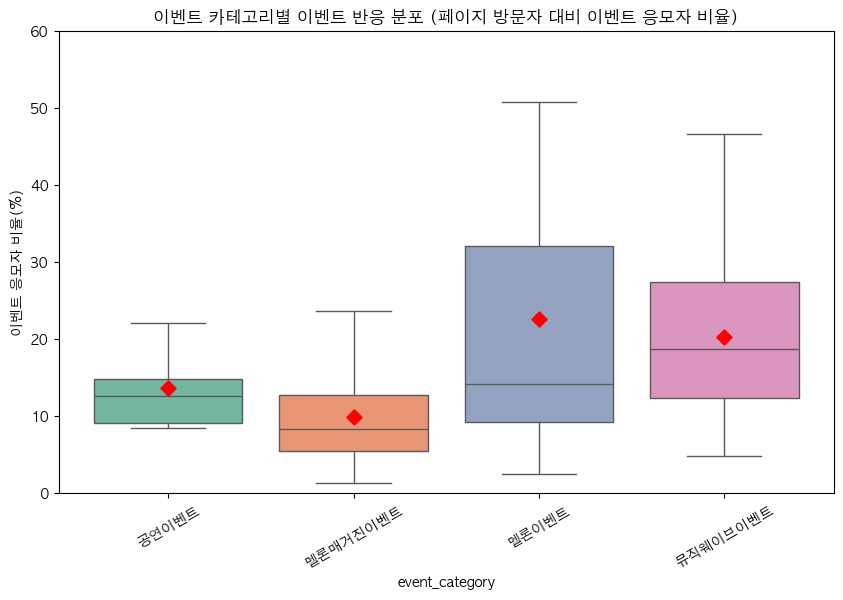

In [11]:
# 1. event_category별 주요 지표 집계
summary = event_user_data.groupby('event_category').agg({
    'event_id': 'nunique',  # 이벤트 건수
    'pv': 'mean',
    'lv': 'mean',
    'event_ent_user_cnt': 'mean',
    'event_user_ratio': 'mean',
    'event_ent_new_prod_user_cnt': 'mean',
    'new_prod_ratio': 'mean'
}).reset_index()

# 소수점 둘째자리까지 반올림해서 표시
summary_rounded = summary.copy()
for col in summary_rounded.columns:
    if summary_rounded[col].dtype in [float, np.float64, np.float32]:
        summary_rounded[col] = summary_rounded[col].round(2)

display(summary_rounded)

# 2. event_category별 지표 bar plot
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
sns.barplot(x='event_category', y='pv', data=summary, ax=axes[0,0])
axes[0,0].set_title('event_category별 페이지뷰(pv)')
sns.barplot(x='event_category', y='lv', data=summary, ax=axes[0,1])
axes[0,1].set_title('event_category별 방문자수(lv)')
sns.barplot(x='event_category', y='event_ent_user_cnt', data=summary, ax=axes[0,2])
axes[0,2].set_title('event_category별 이벤트 응모자수')
sns.barplot(x='event_category', y='event_user_ratio', data=summary, ax=axes[1,0])
axes[1,0].set_title('event_category별 응모자 비율(%)')
sns.barplot(x='event_category', y='event_ent_new_prod_user_cnt', data=summary, ax=axes[1,1])
axes[1,1].set_title('event_category별 신규상품보유 응모자수')
sns.barplot(x='event_category', y='new_prod_ratio', data=summary, ax=axes[1,2])
axes[1,2].set_title('event_category별 신규상품보유자 비율(%)')
for ax in axes.flatten():
    ax.set_xlabel('event_category')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


# 3. event_category별 신규유입 효과 분포 boxplot (event_ent_new_prod_user_cnt) - 아웃라이어 제외, 평균 마커 추가, legend=False
plt.figure(figsize=(10,6))
ax = sns.boxplot(
    x='event_category',
    y='event_ent_new_prod_user_cnt',
    data=event_user_data,
    palette='Set2',
    showfliers=False  # 아웃라이어 제외
)
# 각 카테고리별 평균 마커 추가
means = event_user_data.groupby('event_category')['event_ent_new_prod_user_cnt'].mean()
for i, mean in enumerate(means):
    ax.scatter(i, mean, color='red', marker='D', s=60, zorder=10)
plt.title('이벤트 카테고리별 신규유입 효과 분포 (응모자 내 신규상품 보유자수)')
plt.xlabel('event_category')
plt.ylabel('신규상품보유 응모자수')
plt.xticks(rotation=30)
# legend 제거
ax.legend([],[], frameon=False)
plt.ylim(0, 800)
plt.show()

# 4. event_category별 신규상품보유자 비율 분포 boxplot (new_prod_ratio) - 아웃라이어 제외, 평균 마커 추가, legend=False
plt.figure(figsize=(10,6))
ax = sns.boxplot(
    x='event_category',
    y='new_prod_ratio',
    data=event_user_data,
    palette='Set2',
    showfliers=False  # 아웃라이어 제외
)
means = event_user_data.groupby('event_category')['new_prod_ratio'].mean()
for i, mean in enumerate(means):
    ax.scatter(i, mean, color='red', marker='D', s=60, zorder=10)
plt.title('이벤트 카테고리별 신규상품보유자 비율 분포')
plt.xlabel('event_category')
plt.ylabel('신규상품보유자 비율(%)')
plt.xticks(rotation=30)
# legend 제거
ax.legend([],[], frameon=False)
plt.ylim(0, 30)
plt.show()

# 5. event_category별 이벤트 반응 분포 boxplot (event_user_ratio) - 아웃라이어 제외, 평균 마커 추가, legend=False
plt.figure(figsize=(10,6))
ax = sns.boxplot(
    x='event_category',
    y='event_user_ratio',
    data=event_user_data,
    palette='Set2',
    showfliers=False  # 아웃라이어 제외
)
# 각 카테고리별 평균 마커 추가
means = event_user_data.groupby('event_category')['event_user_ratio'].mean()
for i, mean in enumerate(means):
    ax.scatter(i, mean, color='red', marker='D', s=60, zorder=10)
plt.title('이벤트 카테고리별 이벤트 반응 분포 (페이지 방문자 대비 이벤트 응모자 비율)')
plt.xlabel('event_category')
plt.ylabel('이벤트 응모자 비율(%)')
plt.xticks(rotation=30)
# legend 제거
ax.legend([],[], frameon=False)
plt.ylim(0, 60)
plt.show()

In [28]:
# pandas를 사용하여 CSV 파일 로드
import pandas as pd

# CSV 파일 경로
csv_file_path = "event_age_gndr_user_data.csv"

# CSV 파일 읽기
try:
    event_age_gndr_user_data = pd.read_csv(csv_file_path)
    print("CSV 파일이 성공적으로 로드되었습니다.")
    print(event_age_gndr_user_data.head())  # 데이터 미리보기
except FileNotFoundError:
    print(f"파일을 찾을 수 없습니다: {csv_file_path}")
except Exception as e:
    print(f"CSV 파일 로드 중 오류 발생: {e}")

CSV 파일이 성공적으로 로드되었습니다.
   event_id  category_id event_category                         title  \
0     36277       100067          공연이벤트  노엘 갤러거 하이 플라잉 버즈 내한공연 초대 이벤트   
1     36277       100067          공연이벤트  노엘 갤러거 하이 플라잉 버즈 내한공연 초대 이벤트   
2     36277       100067          공연이벤트  노엘 갤러거 하이 플라잉 버즈 내한공연 초대 이벤트   
3     36277       100067          공연이벤트  노엘 갤러거 하이 플라잉 버즈 내한공연 초대 이벤트   
4     36277       100067          공연이벤트  노엘 갤러거 하이 플라잉 버즈 내한공연 초대 이벤트   

         start_date          end_date gndr    age    pv   lv  \
0  2024-07-15 12:00  2024-07-19 23:59    남  10대이하   441  256   
1  2024-07-15 12:00  2024-07-19 23:59    남    20대  1007  694   
2  2024-07-15 12:00  2024-07-19 23:59    남    30대  1229  814   
3  2024-07-15 12:00  2024-07-19 23:59    남    40대   730  573   
4  2024-07-15 12:00  2024-07-19 23:59    남    50대   579  395   

   event_ent_user_cnt  event_user_ratio  event_ent_new_prod_user_cnt  \
0                27.0             10.55                          1.0   
1        

In [29]:
event_age_gndr_user_data['event_ent_user_cnt'] = event_age_gndr_user_data['event_ent_user_cnt'].fillna(0).astype(int)
event_age_gndr_user_data['event_ent_new_prod_user_cnt'] = event_age_gndr_user_data['event_ent_new_prod_user_cnt'].fillna(0).astype(int)



In [30]:
event_age_gndr_user_data.head()

,event_id,category_id,event_category,title,start_date,end_date,gndr,age,pv,lv,event_ent_user_cnt,event_user_ratio,event_ent_new_prod_user_cnt,event_ent_new_prod_user_ratio
0,36277,100067,공연이벤트,노엘 갤러거 하이 플라잉 버즈 내한공연 초대 이벤트,2024-07-15 12:00,2024-07-19 23:59,남,10대이하,441,256,27,10.55,1,3.70
1,36277,100067,공연이벤트,노엘 갤러거 하이 플라잉 버즈 내한공연 초대 이벤트,2024-07-15 12:00,2024-07-19 23:59,남,20대,1007,694,69,9.94,2,2.90
2,36277,100067,공연이벤트,노엘 갤러거 하이 플라잉 버즈 내한공연 초대 이벤트,2024-07-15 12:00,2024-07-19 23:59,남,30대,1229,814,65,7.99,1,1.54
3,36277,100067,공연이벤트,노엘 갤러거 하이 플라잉 버즈 내한공연 초대 이벤트,2024-07-15 12:00,2024-07-19 23:59,남,40대,730,573,32,5.58,0,0.00
4,36277,100067,공연이벤트,노엘 갤러거 하이 플라잉 버즈 내한공연 초대 이벤트,2024-07-15 12:00,2024-07-19 23:59,남,50대,579,395,32,8.10,1,3.13


,event_category,gndr,age,event_ent_user_cnt,event_user_ratio,lv
0,공연이벤트,남,10대이하,88.85,15.93,465.55
1,공연이벤트,남,20대,161.90,12.39,1164.50
2,공연이벤트,남,30대,158.35,12.21,1198.00
3,공연이벤트,남,40대,128.50,10.71,1030.40
4,공연이벤트,남,50대,74.05,11.16,596.80
5,공연이벤트,남,60대이상,13.90,7.80,164.00
6,공연이벤트,여,10대이하,171.95,15.90,922.70
7,공연이벤트,여,20대,411.85,16.11,2314.50
8,공연이벤트,여,30대,316.30,14.35,1988.50
9,공연이벤트,여,40대,285.70,12.44,2031.95


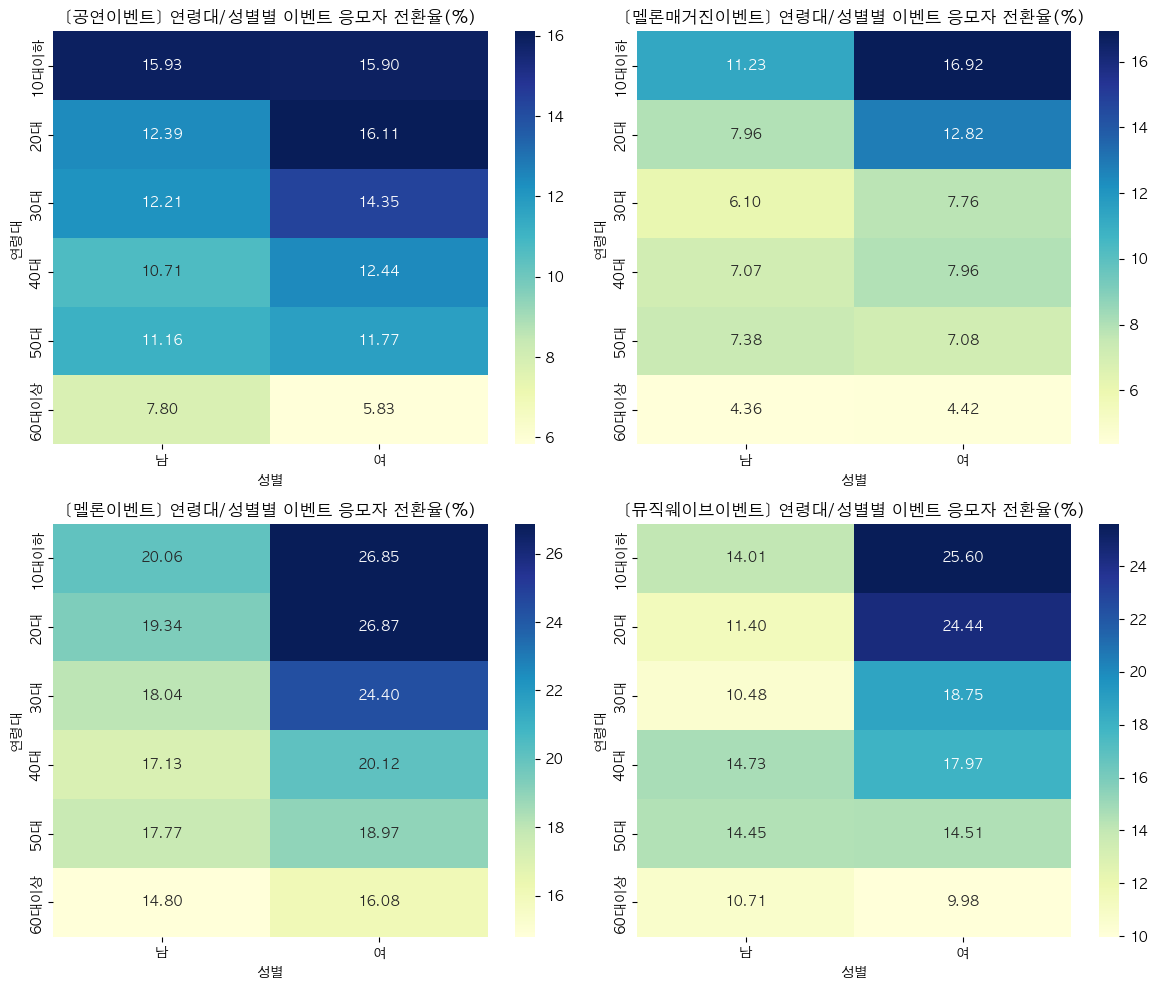

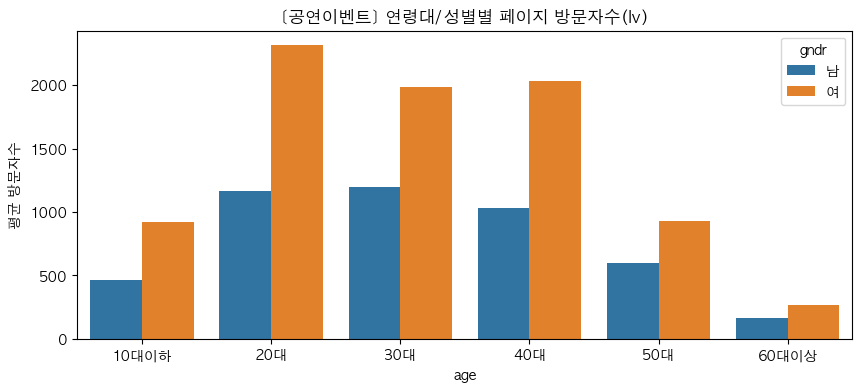

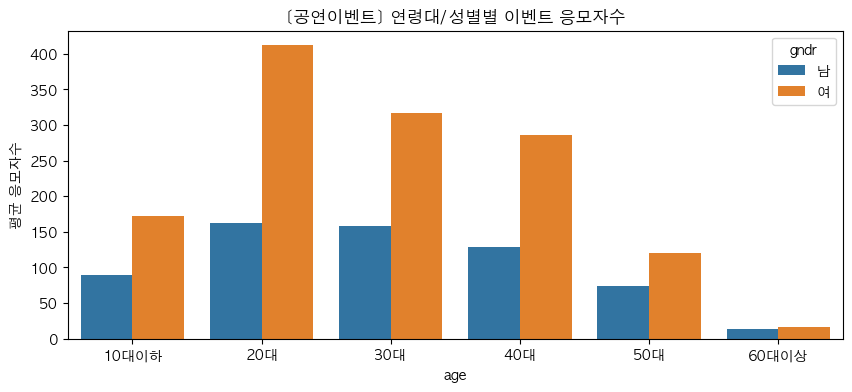

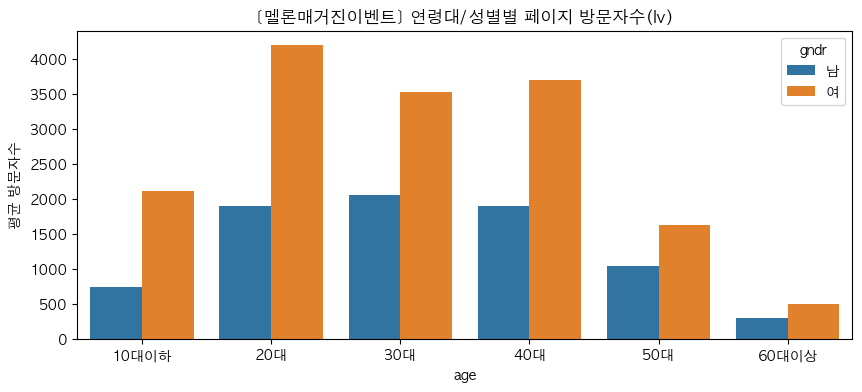

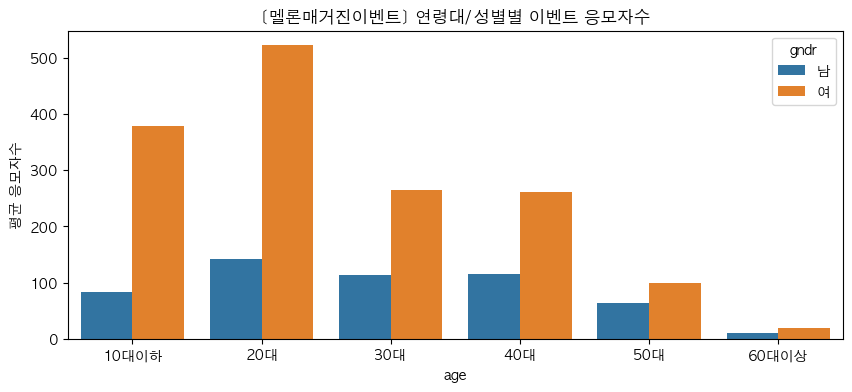

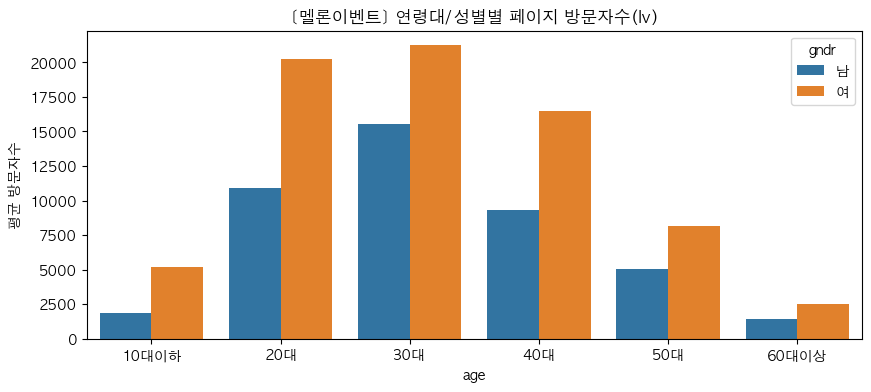

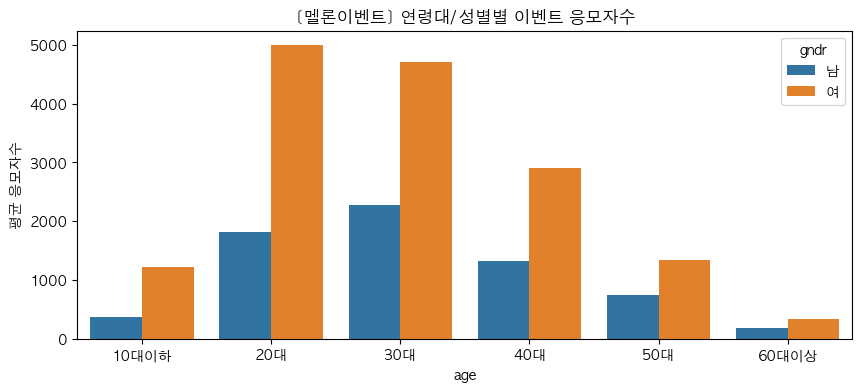

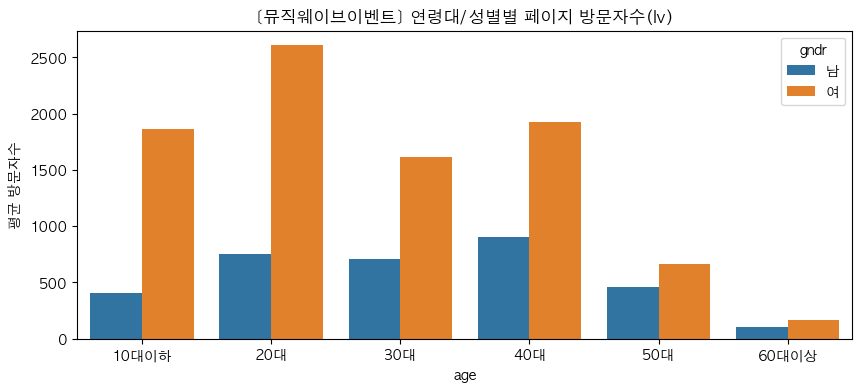

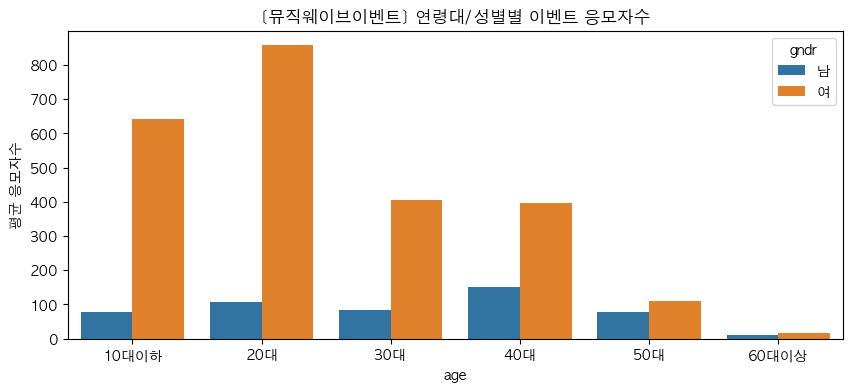

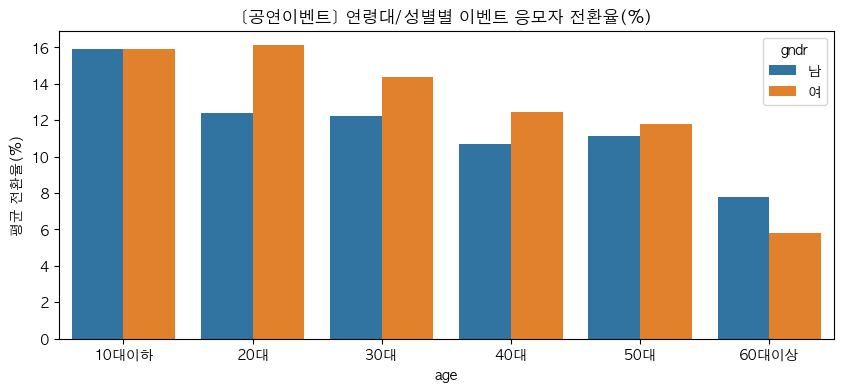

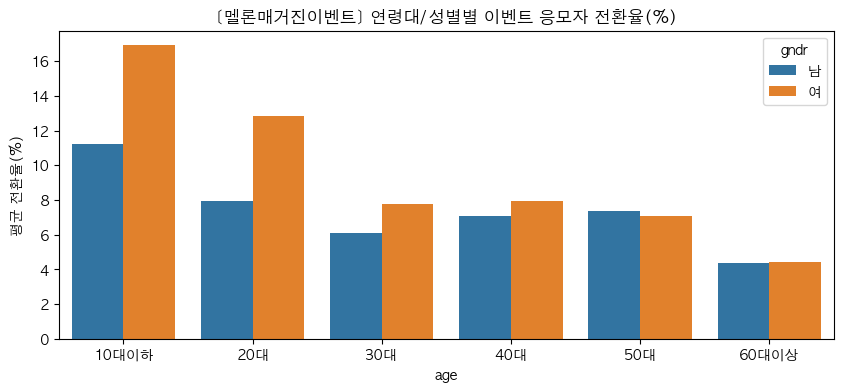

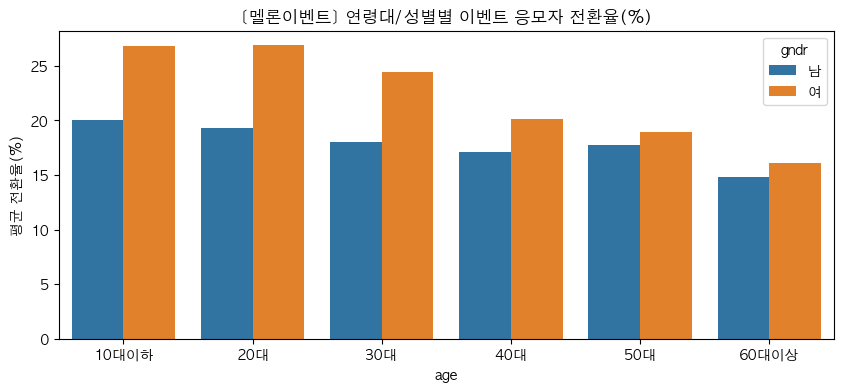

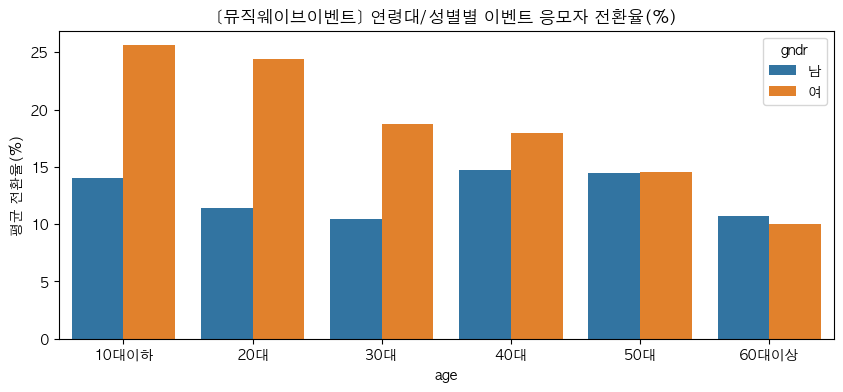

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pivot Table 생성: event_category별, 성별, 연령대별 주요 지표 평균
pivot = pd.pivot_table(
    event_age_gndr_user_data,
    index=['event_category', 'gndr', 'age'],
    values=['lv', 'event_ent_user_cnt', 'event_user_ratio'],
    aggfunc='mean'
).reset_index()

# 소수점 둘째자리까지 반올림
pivot['lv'] = pivot['lv'].round(2)
pivot['event_ent_user_cnt'] = pivot['event_ent_user_cnt'].round(2)
pivot['event_user_ratio'] = pivot['event_user_ratio'].round(2)

display(pivot)

# 2. event_category별 연령대/성별별 전환율(응모자 비율) heatmap
import matplotlib.pyplot as plt
import seaborn as sns

# event_category별 연령대/성별별 전환율(응모자 비율) heatmap을 한 plot에 2x2로 출력
cats = pivot['event_category'].unique()
n = len(cats)
ncols = 2
nrows = (n + 1) // 2

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5 * nrows))
axes = axes.flatten()

for idx, cat in enumerate(cats):
    data = pivot[pivot['event_category'] == cat]
    heatmap_data = data.pivot(index='age', columns='gndr', values='event_user_ratio')
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap='YlGnBu', ax=axes[idx])
    axes[idx].set_title(f"[{cat}] 연령대/성별별 이벤트 응모자 전환율(%)")
    axes[idx].set_ylabel('연령대')
    axes[idx].set_xlabel('성별')

# 빈 subplot 숨기기 (event_category가 3개일 때 등)
for j in range(idx + 1, nrows * ncols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 3. event_category별 연령대/성별별 방문자수, 응모자수 barplot
for cat in pivot['event_category'].unique():
    data = pivot[pivot['event_category'] == cat]
    plt.figure(figsize=(10,4))
    sns.barplot(x='age', y='lv', hue='gndr', data=data)
    plt.title(f"[{cat}] 연령대/성별별 페이지 방문자수(lv)")
    plt.ylabel('평균 방문자수')
    plt.show()
    
    plt.figure(figsize=(10,4))
    sns.barplot(x='age', y='event_ent_user_cnt', hue='gndr', data=data)
    plt.title(f"[{cat}] 연령대/성별별 이벤트 응모자수")
    plt.ylabel('평균 응모자수')
    plt.show()

# 4. event_category별 연령대/성별별 전환율 barplot
for cat in pivot['event_category'].unique():
    data = pivot[pivot['event_category'] == cat]
    plt.figure(figsize=(10,4))
    sns.barplot(x='age', y='event_user_ratio', hue='gndr', data=data)
    plt.title(f"[{cat}] 연령대/성별별 이벤트 응모자 전환율(%)")
    plt.ylabel('평균 전환율(%)')
    plt.show()